# NMR & Hall Probe Data -- SPS MBB (~176 RPM)

| File | Supercycle |
|------|------------|
| `20260306_152447_...md1full_.h5` | 200 GeV (MD1 full) |
| `20260306_153650_...md1flat_.h5` | 26 GeV (MD1 flat) |

Columns in `RawData/SFTPRO-NMR`: time (ms), NMR (T), Hall probe (T), NMR lock (0/1)


---
## 1. Imports & Configuration


In [1]:
import sys
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (16, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

MEAS_DIR = REPO_ROOT / "measurements" / "MBB" / "2026-03-06_max_speed_NMR"

H5_FILES = {
    "200 GeV": MEAS_DIR / "20260306_152447_TestCaylarTeslameterNMR20_ md1full_.h5",
    "26 GeV":  MEAS_DIR / "20260306_153650_TestCaylarTeslameterNMR20_ md1flat_.h5",
}

for name, p in H5_FILES.items():
    assert p.exists(), f"{name}: {p}"
    print(f"  {name}: {p.name}")
print("Files found.")


  200 GeV: 20260306_152447_TestCaylarTeslameterNMR20_ md1full_.h5
  26 GeV: 20260306_153650_TestCaylarTeslameterNMR20_ md1flat_.h5
Files found.


---
## 2. Load Data


In [2]:
datasets = {}

for name, fpath in H5_FILES.items():
    with h5py.File(fpath, 'r') as f:
        data = f['RawData/SFTPRO-NMR'][:]
        start_s = f['RawData/CaylarStartTime(s)'][0, 0]

    # Columns: time_ms, NMR_T, Hall_T, lock
    t_ms  = data[:, 0]
    nmr   = data[:, 1]
    hall  = data[:, 2]
    lock  = data[:, 3].astype(int)

    # Convert time to seconds from start of day
    t_s = start_s + t_ms / 1000.0

    datasets[name] = {
        't_s': t_s, 't_ms': t_ms,
        'nmr': nmr, 'hall': hall, 'lock': lock,
        'start_s': start_s,
    }
    n_locked = np.sum(lock == 1)
    print(f"{name}: {len(data)} samples, {n_locked} locked ({100*n_locked/len(data):.1f}%)")
    print(f"  Hall range: {hall.min():.4f} to {hall.max():.4f} T")
    if n_locked > 0:
        print(f"  NMR range (locked): {nmr[lock==1].min():.6f} to {nmr[lock==1].max():.6f} T")


200 GeV: 86091 samples, 1138 locked (1.3%)
  Hall range: 0.8020 to 2.1716 T
  NMR range (locked): -2.027519 to -1.629109 T
26 GeV: 92604 samples, 1105 locked (1.2%)
  Hall range: 1.6590 to 2.1717 T
  NMR range (locked): -2.027748 to -1.793911 T


---
## 3. Hall Probe & NMR vs Time


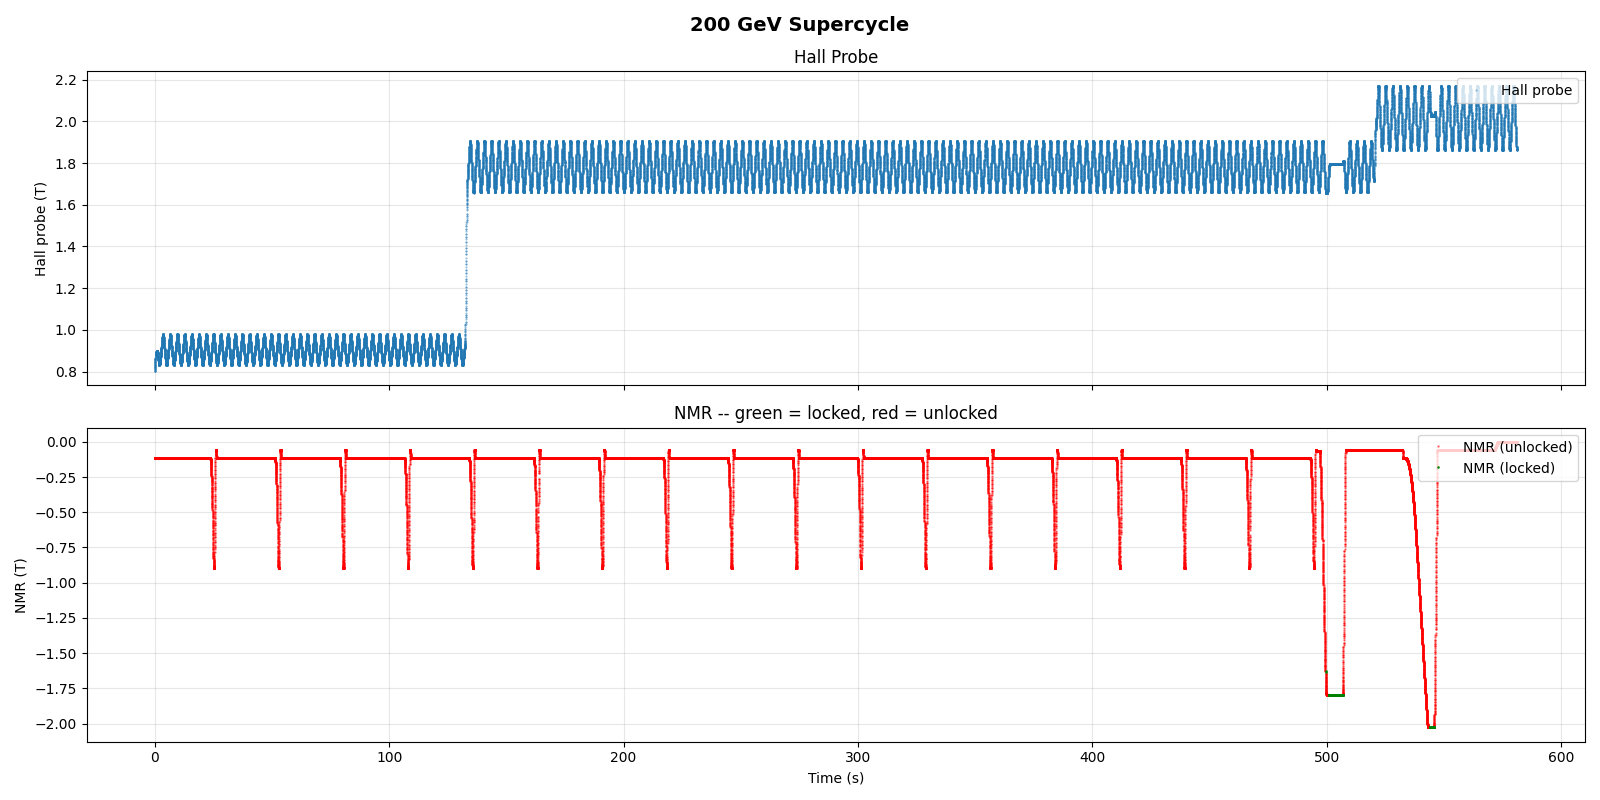

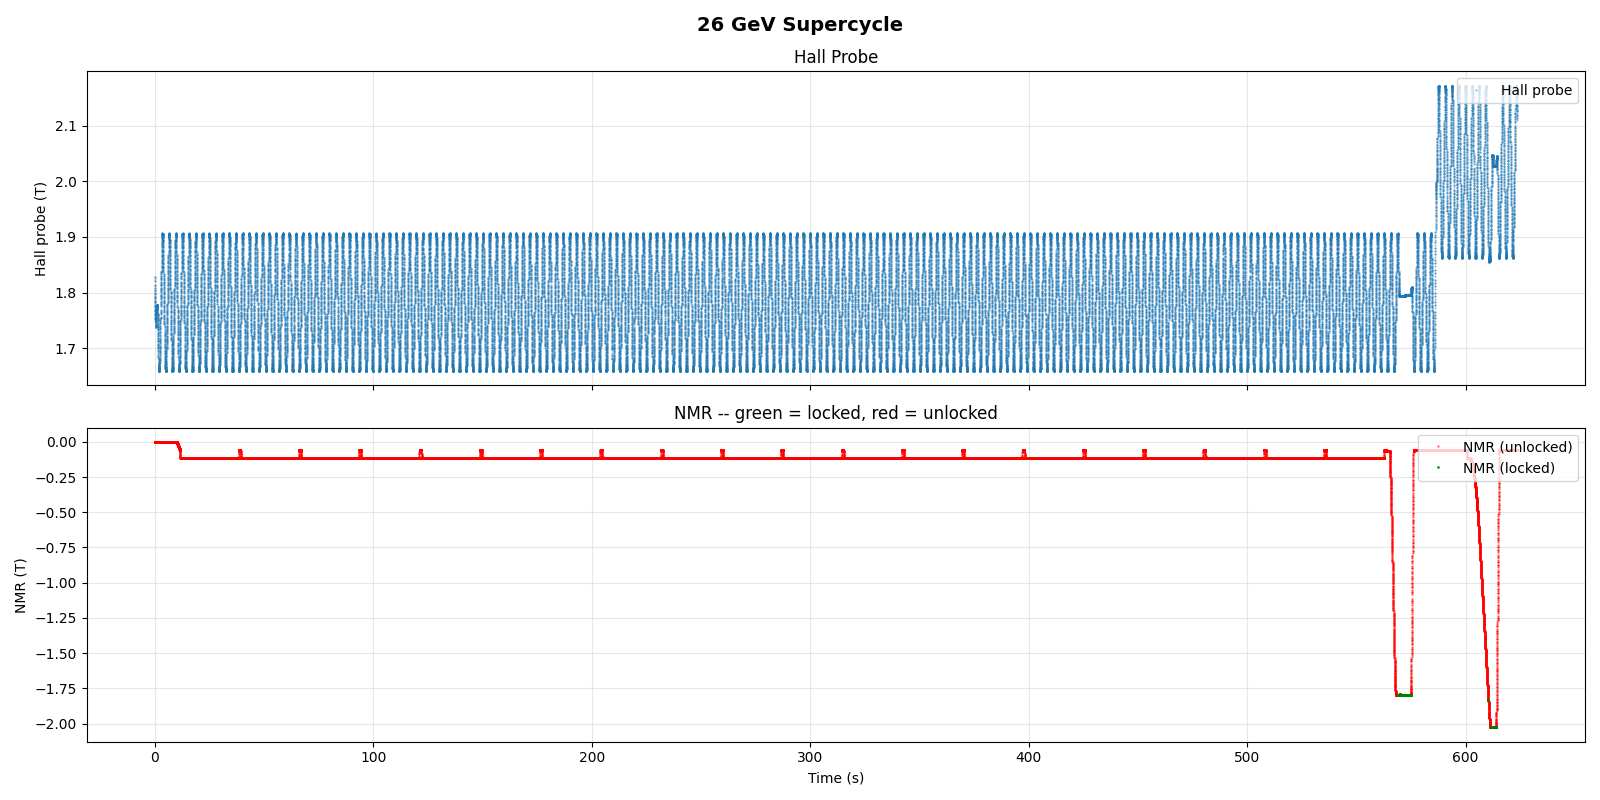

In [3]:
for name, ds in datasets.items():
    t_s = ds['t_s']
    nmr = ds['nmr']
    hall = ds['hall']
    lock = ds['lock']

    t_rel = t_s - t_s[0]

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'{name} Supercycle', fontsize=14, fontweight='bold')

    # --- Hall probe (top) ---
    ax = axes[0]
    ax.plot(t_rel, hall, '.', markersize=1, color='tab:blue', alpha=0.5, label='Hall probe')
    ax.set_ylabel('Hall probe (T)')
    ax.set_title('Hall Probe')
    ax.legend(loc='upper right')

    # --- NMR (bottom) ---
    ax = axes[1]
    mask_locked = lock == 1
    mask_unlocked = lock == 0

    ax.plot(t_rel[mask_unlocked], nmr[mask_unlocked], '.', markersize=1.5,
            color='red', alpha=0.5, label='NMR (unlocked)')
    ax.plot(t_rel[mask_locked], nmr[mask_locked], '.', markersize=2,
            color='green', alpha=0.8, label='NMR (locked)')
    ax.set_ylabel('NMR (T)')
    ax.set_xlabel('Time (s)')
    ax.set_title('NMR -- green = locked, red = unlocked')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


---
## 4. NMR Locked Zoom


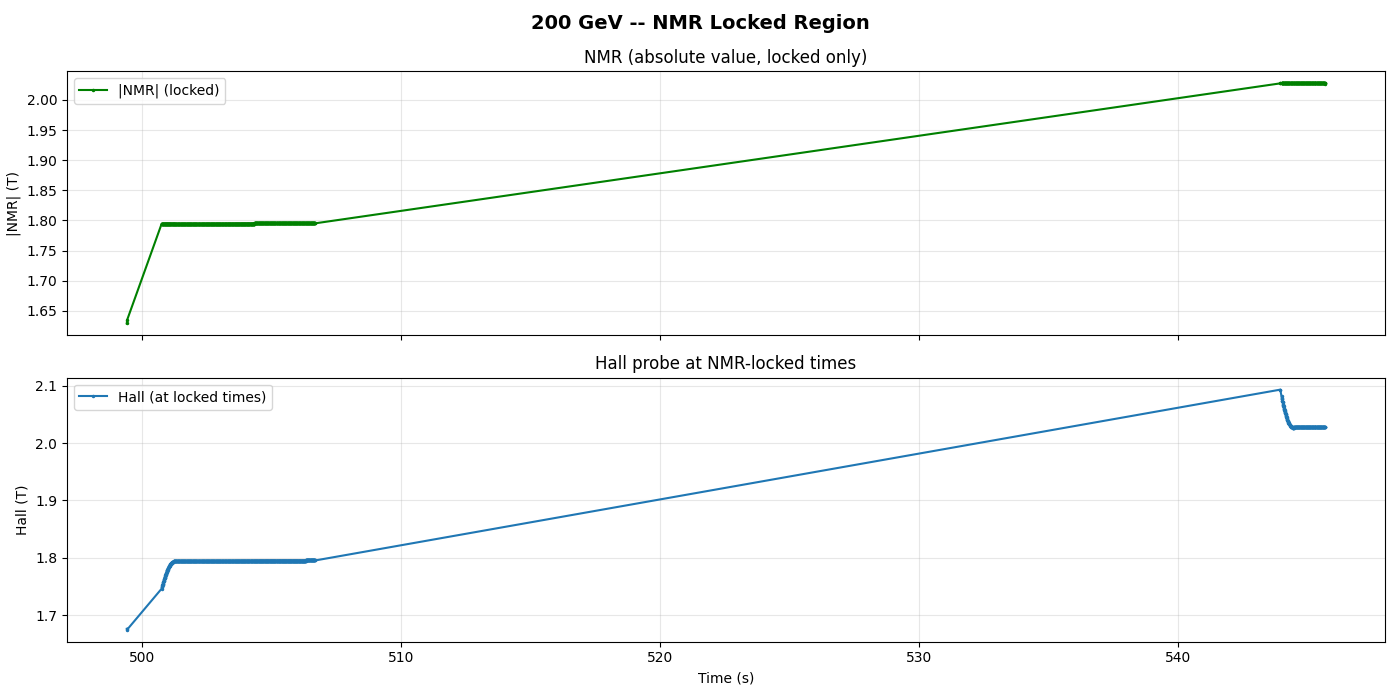


200 GeV NMR locked statistics:
  Samples    : 1138
  Time range : 499.4 -- 545.7 s
  |NMR| mean : 1.846183 T
  |NMR| std  : 0.097166 T
  |NMR| range: 1.629109 -- 2.027519 T
  Hall mean  : 1.846297 T


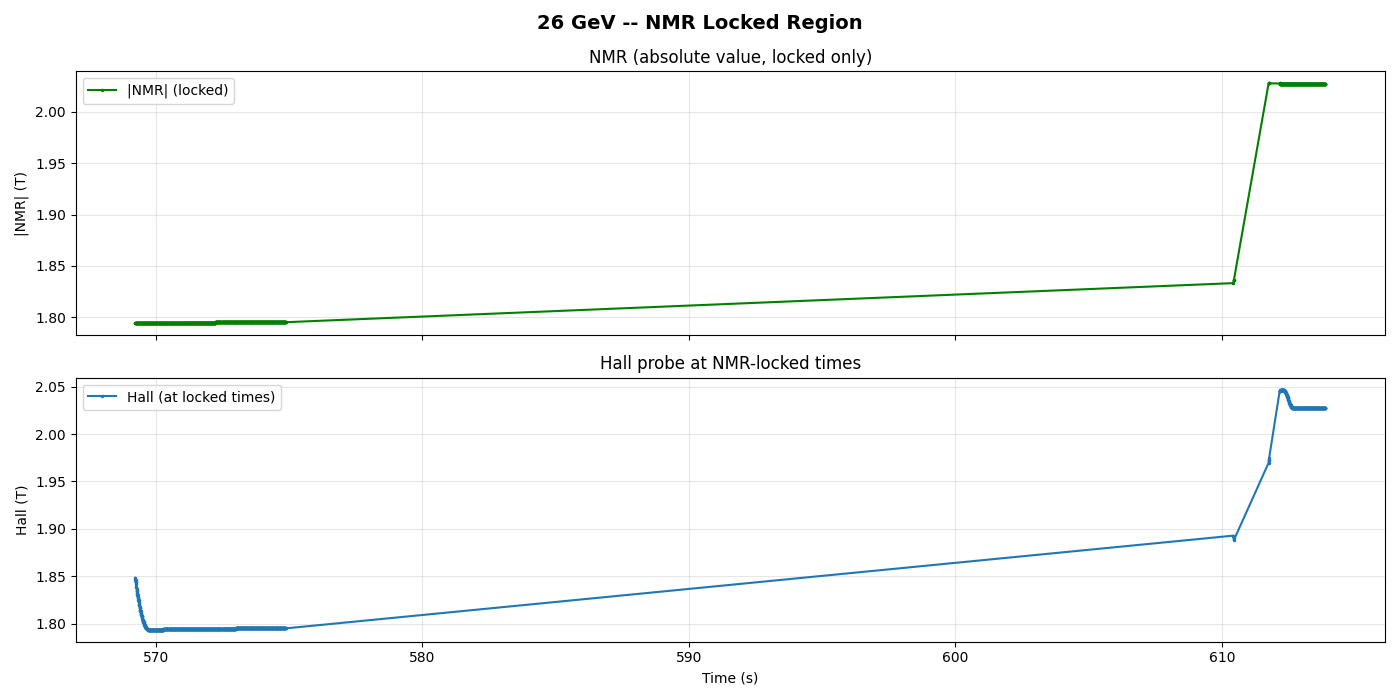


26 GeV NMR locked statistics:
  Samples    : 1105
  Time range : 569.2 -- 613.9 s
  |NMR| mean : 1.849815 T
  |NMR| std  : 0.098819 T
  |NMR| range: 1.793911 -- 2.027748 T
  Hall mean  : 1.851833 T


In [4]:
for name, ds in datasets.items():
    lock = ds['lock']
    nmr = ds['nmr']
    hall = ds['hall']
    t_rel = ds['t_s'] - ds['t_s'][0]

    mask = lock == 1
    if mask.sum() == 0:
        print(f"{name}: no locked NMR samples")
        continue

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f'{name} -- NMR Locked Region', fontsize=14, fontweight='bold')

    t_locked = t_rel[mask]
    nmr_locked = nmr[mask]
    hall_locked = hall[mask]

    ax = axes[0]
    ax.plot(t_locked, np.abs(nmr_locked), '.-', markersize=3, color='green', label='|NMR| (locked)')
    ax.set_ylabel('|NMR| (T)')
    ax.set_title('NMR (absolute value, locked only)')
    ax.legend()

    ax = axes[1]
    ax.plot(t_locked, hall_locked, '.-', markersize=3, color='tab:blue', label='Hall (at locked times)')
    ax.set_ylabel('Hall (T)')
    ax.set_xlabel('Time (s)')
    ax.set_title('Hall probe at NMR-locked times')
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{name} NMR locked statistics:")
    print(f"  Samples    : {mask.sum()}")
    print(f"  Time range : {t_locked[0]:.1f} -- {t_locked[-1]:.1f} s")
    print(f"  |NMR| mean : {np.abs(nmr_locked).mean():.6f} T")
    print(f"  |NMR| std  : {np.abs(nmr_locked).std():.6f} T")
    print(f"  |NMR| range: {np.abs(nmr_locked).min():.6f} -- {np.abs(nmr_locked).max():.6f} T")
    print(f"  Hall mean  : {hall_locked.mean():.6f} T")


---
## 5. Hall vs |NMR| Correlation (Locked)


200 GeV: |NMR| = 0.966580 * Hall + (0.061589)
  Residual RMS: 8199.5 uT


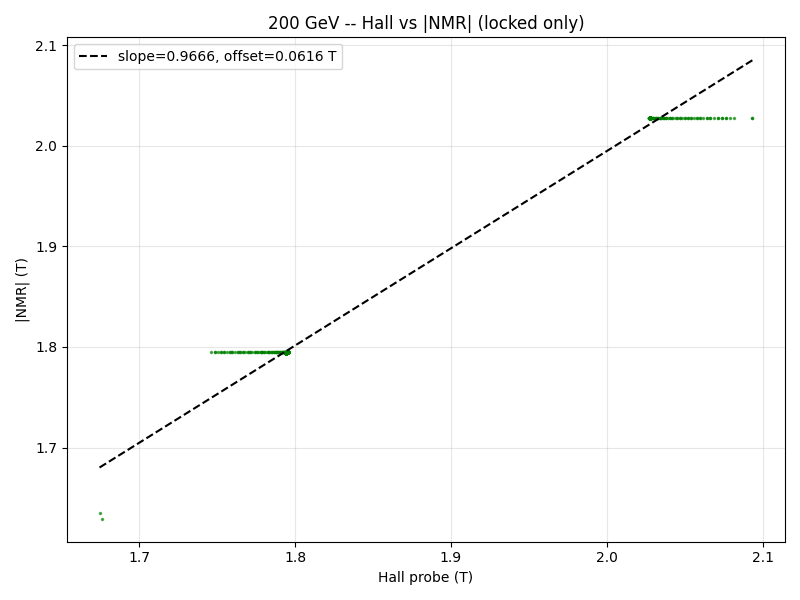

26 GeV: |NMR| = 0.989103 * Hall + (0.018162)
  Residual RMS: 8284.4 uT


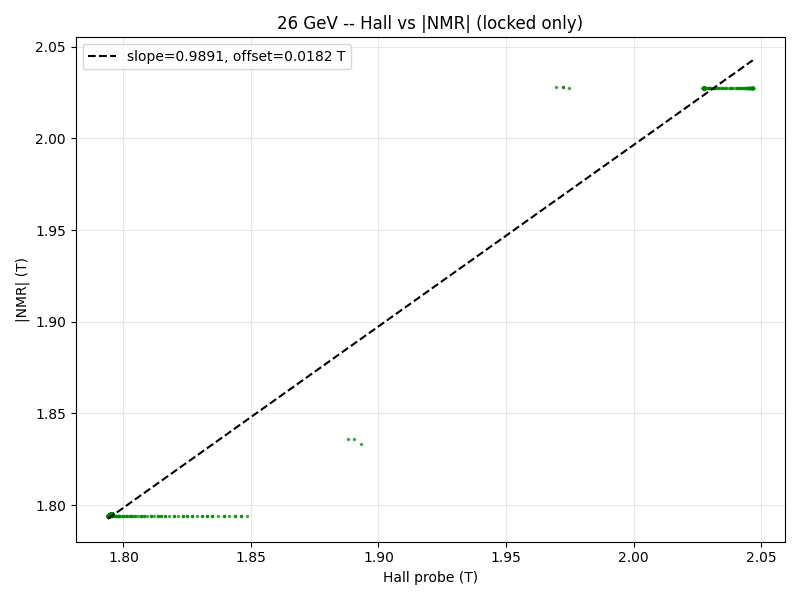

In [5]:
for name, ds in datasets.items():
    lock = ds['lock']
    nmr = ds['nmr']
    hall = ds['hall']
    mask = lock == 1
    if mask.sum() < 2:
        print(f"{name}: too few locked samples for correlation")
        continue

    nmr_abs = np.abs(nmr[mask])
    hall_l = hall[mask]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(hall_l, nmr_abs, '.', markersize=3, color='green', alpha=0.6)
    ax.set_xlabel('Hall probe (T)')
    ax.set_ylabel('|NMR| (T)')
    ax.set_title(f'{name} -- Hall vs |NMR| (locked only)')

    coeffs = np.polyfit(hall_l, nmr_abs, 1)
    x_fit = np.linspace(hall_l.min(), hall_l.max(), 100)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), '--', color='black',
            label=f'slope={coeffs[0]:.4f}, offset={coeffs[1]:.4f} T')
    ax.legend()

    residuals = nmr_abs - np.polyval(coeffs, hall_l)
    print(f"{name}: |NMR| = {coeffs[0]:.6f} * Hall + ({coeffs[1]:.6f})")
    print(f"  Residual RMS: {np.sqrt(np.mean(residuals**2))*1e6:.1f} uT")

    plt.tight_layout()
    plt.show()


---
## 6. Summary Table


In [6]:
import pandas as pd

rows = []
for name, ds in datasets.items():
    lock = ds['lock']
    nmr = ds['nmr']
    hall = ds['hall']
    t_rel = ds['t_s'] - ds['t_s'][0]

    row = {
        'Supercycle': name,
        'Total samples': len(nmr),
        'Locked samples': int(np.sum(lock == 1)),
        'Duration (s)': f"{t_rel[-1]:.0f}",
        'Hall min (T)': f"{hall.min():.4f}",
        'Hall max (T)': f"{hall.max():.4f}",
    }
    mask = lock == 1
    if mask.sum() > 0:
        row['|NMR| min (T)'] = f"{np.abs(nmr[mask]).min():.6f}"
        row['|NMR| max (T)'] = f"{np.abs(nmr[mask]).max():.6f}"
        row['|NMR| mean (T)'] = f"{np.abs(nmr[mask]).mean():.6f}"
    else:
        row['|NMR| min (T)'] = 'N/A'
        row['|NMR| max (T)'] = 'N/A'
        row['|NMR| mean (T)'] = 'N/A'
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary)


,Supercycle,Total samples,Locked samples,Duration (s),Hall min (T),Hall max (T),|NMR| min (T),|NMR| max (T),|NMR| mean (T)
0,200 GeV,86091,1138,581,0.8020,2.1716,1.629109,2.027519,1.846183
1,26 GeV,92604,1105,623,1.6590,2.1717,1.793911,2.027748,1.849815
